In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
file_path = "/home/onyxia/work/data/FOIL2013/trip_data_1.parquet"

In [6]:
df = pd.read_parquet(file_path, engine='fastparquet')

In [7]:
print("Aperçu des données :")
print(df.head())
print (df.columns)

Aperçu des données :
  pickup_datetime    dropoff_datetime  passenger_count  trip_time_in_secs  \
0      2013-01-01 2013-01-01 00:28:00                1               1680   
1      2013-01-01 2013-01-01 00:06:00                5                360   
2      2013-01-01 2013-01-01 00:10:00                1                600   
3      2013-01-01 2013-01-01 00:08:00                2                480   
4      2013-01-01 2013-01-01 00:16:00                4                960   

   trip_distance  pickup_longitude  pickup_latitude  dropoff_longitude  \
0     6340.81536        -73.990784        40.760880         -73.954185   
1     1577.15712        -73.978325        40.778091         -73.981834   
2     4457.88288        -73.989616        40.729988         -74.013779   
3     2703.69792        -73.981575        40.767632         -73.977737   
4     6517.84320        -74.000526        40.737343         -73.977226   

   dropoff_latitude  
0         40.778847  
1         40.768639  
2    

In [8]:
df2 = pd.read_csv("/home/onyxia/work/data/automated_traffic_volume_counts.csv")

In [ ]:
df2[["HH"]].value_counts()

In [10]:
df2[["Vol"]].value_counts()

Vol  
 0       92906
 1       23098
 2       23007
 3       22151
 4       21516
         ...  
 5425        1
-1           1
 4609        1
 4612        1
 4621        1
Name: count, Length: 3069, dtype: int64

In [9]:
df2.head()

,RequestID,Boro,Yr,M,D,HH,MM,Vol,SegmentID,WktGeom,street,fromSt,toSt,Direction
0,32970,Queens,2021,4,30,2,0,0,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB
1,32970,Queens,2021,4,30,2,15,1,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB
2,32970,Queens,2021,4,30,2,30,0,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB
3,32970,Queens,2021,4,30,2,45,0,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB
4,32970,Queens,2021,4,30,3,0,1,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB


In [13]:
df.head()

,pickup_datetime,dropoff_datetime,passenger_count,trip_time_in_secs,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
0,2013-01-01,2013-01-01 00:28:00,1,1680,6340.81536,-73.990784,40.760880,-73.954185,40.778847
1,2013-01-01,2013-01-01 00:06:00,5,360,1577.15712,-73.978325,40.778091,-73.981834,40.768639
2,2013-01-01,2013-01-01 00:10:00,1,600,4457.88288,-73.989616,40.729988,-74.013779,40.705036
3,2013-01-01,2013-01-01 00:08:00,2,480,2703.69792,-73.981575,40.767632,-73.977737,40.757927
4,2013-01-01,2013-01-01 00:16:00,4,960,6517.84320,-74.000526,40.737343,-73.977226,40.783607


In [15]:
df.columns

Index(['pickup_datetime', 'dropoff_datetime', 'passenger_count',
       'trip_time_in_secs', 'trip_distance', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude'],
      dtype='object')

In [17]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

In [20]:
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day'] = df['pickup_datetime'].dt.day_name()  # Jour de la semaine
df['pickup_month'] = df['pickup_datetime'].dt.month
df['pickup_date'] = df['pickup_datetime'].dt.date  # Date sans l'heure

/tmp/ipykernel_34846/185834521.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_trips.index, y=hourly_trips.values, palette="viridis")


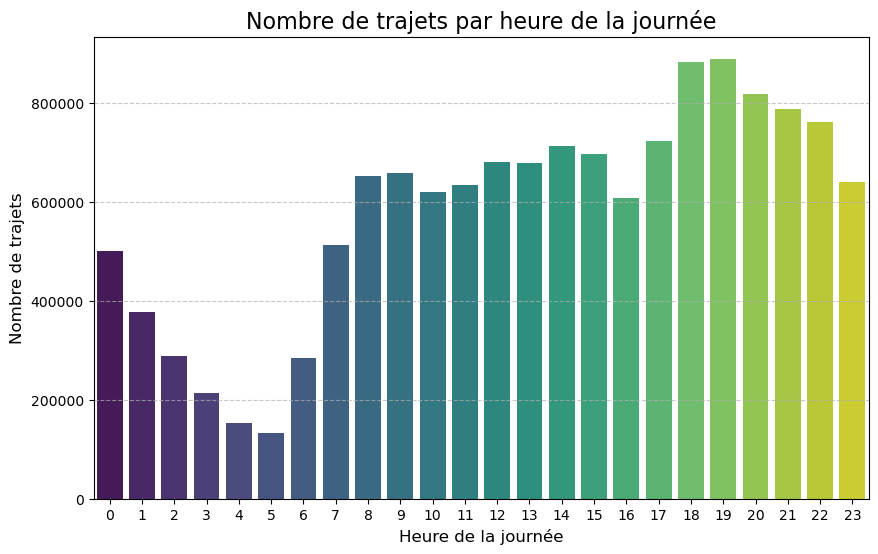

In [22]:
hourly_trips = df['pickup_hour'].value_counts().sort_index()

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(x=hourly_trips.index, y=hourly_trips.values, palette="viridis")
plt.title("Nombre de trajets par heure de la journée", fontsize=16)
plt.xlabel("Heure de la journée", fontsize=12)
plt.ylabel("Nombre de trajets", fontsize=12)
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_34846/2072531354.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekly_trips.index, y=weekly_trips.values, palette="pastel")


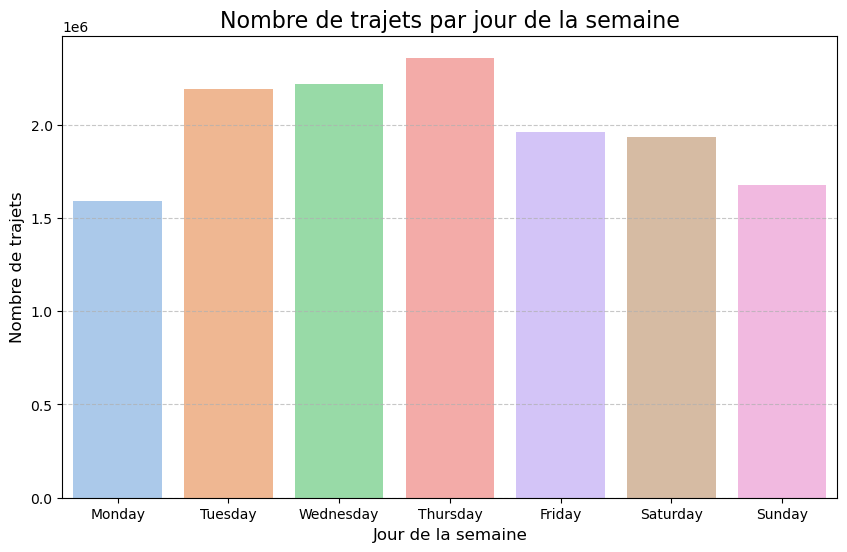

In [23]:
# Compter les trajets par jour de la semaine
weekly_trips = df['pickup_day'].value_counts()

# Ordonner les jours de la semaine
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_trips = weekly_trips.reindex(ordered_days)

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(x=weekly_trips.index, y=weekly_trips.values, palette="pastel")
plt.title("Nombre de trajets par jour de la semaine", fontsize=16)
plt.xlabel("Jour de la semaine", fontsize=12)
plt.ylabel("Nombre de trajets", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

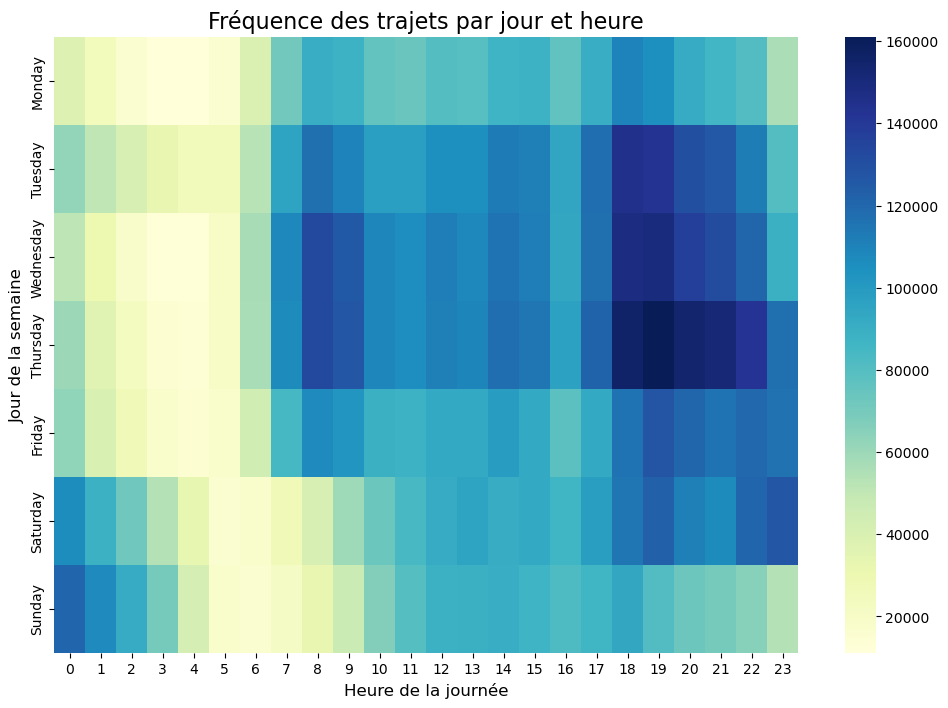

In [24]:
# Grouper les trajets par jour de la semaine et heure
heatmap_data = df.groupby(['pickup_day', 'pickup_hour']).size().unstack()

# Réordonner les jours
heatmap_data = heatmap_data.reindex(index=ordered_days)

# Visualisation
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=False, cbar=True)
plt.title("Fréquence des trajets par jour et heure", fontsize=16)
plt.xlabel("Heure de la journée", fontsize=12)
plt.ylabel("Jour de la semaine", fontsize=12)
plt.show()

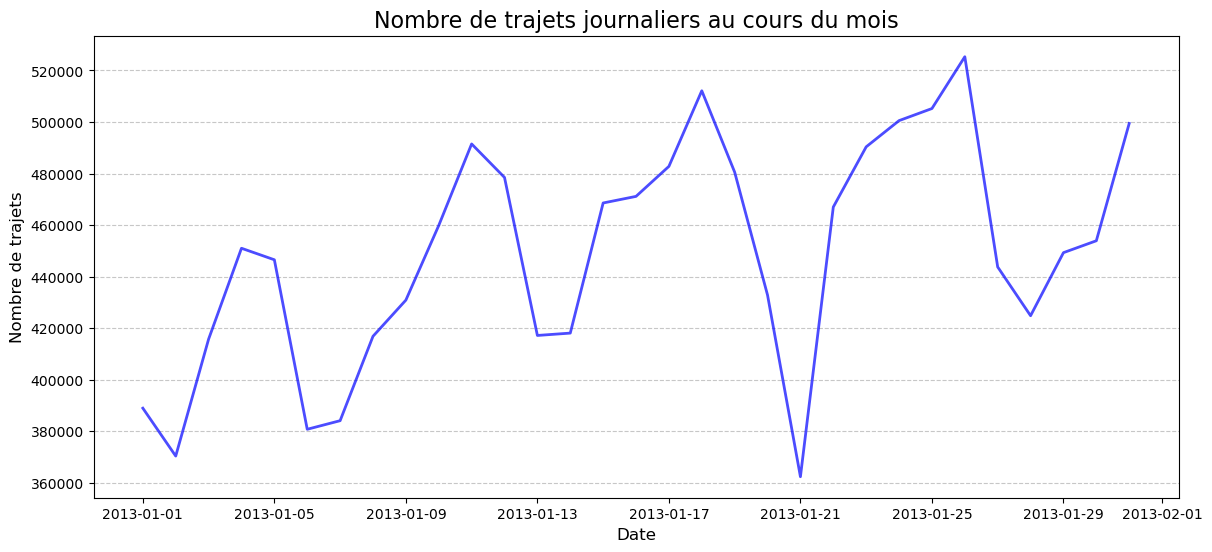

In [30]:
# Compter les trajets par jour du mois
daily_trips = df.groupby('pickup_date').size()

# Visualisation
plt.figure(figsize=(14, 6))
daily_trips.plot(color="blue", alpha=0.7, linewidth=2)
plt.title("Nombre de trajets journaliers au cours du mois", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Nombre de trajets", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()